# 🧠 AI Personal Chef — Notebook 2
## Recipe Recommender (ML) — TF-IDF + Cosine Similarity

This notebook builds a **complete recipe recommendation system** from scratch.

| Step | Topic |
|------|-------|
| 1 | Load the clean dataset from Notebook 1 |
| 2 | Understand TF-IDF (theory + worked example) |
| 3 | Build the TF-IDF matrix |
| 4 | Implement cosine similarity |
| 5 | Build the `recommend()` function |
| 6 | Add dietary filters (high protein / low calorie / diet labels) |
| 7 | Evaluate the recommender |
| 8 | Interactive query demo |
| 9 | Save the fitted model |


## Step 1 — Load Clean Dataset

In [1]:
import warningswarnings.filterwarnings("ignore")import numpy as npimport pandas as pdimport matplotlib.pyplot as pltimport seaborn as snsfrom pathlib import Pathpd.set_option("display.max_colwidth", 70)pd.set_option("display.float_format", "{:.2f}".format)sns.set_theme(style="whitegrid")plt.rcParams["figure.dpi"] = 110CLEAN_PATH = Path("data/recipes_clean.csv")if not CLEAN_PATH.exists():    raise FileNotFoundError(        "Run Notebook 1 first to generate data/recipes_clean.csv"    )df = pd.read_csv(CLEAN_PATH)print("Loaded:", df.shape[0], "recipes,", df.shape[1], "columns")df[["recipe_name","ingredients_text","calories","protein_g","is_high_protein"]].head(5)

Loaded: 1000 recipes, 27 columns


,recipe_name,ingredients_text,calories,protein_g,is_high_protein
0,Grilled Lemon Herb Chicken #1,chicken breast black pepper garlic olive oil,209.10,9.30,False
1,Pan-Seared Salmon with Dill #2,dill cream cheese lemon capers salmon fillet butter chives,343.40,24.00,False
2,Classic Beef Burger #3,garlic tomato paste buns cheddar cheese,715.50,38.10,True
3,Sesame Ginger Tofu Stir-Fry #4,sesame oil cornstarch soy sauce green onions ginger,500.10,13.20,False
4,Red Lentil Dal #5,spinach turmeric red lentils cumin garam masala coconut milk,352.50,17.30,False


In [2]:
# Quick sanity check on ingredients_text
print("Sample ingredients_text values:")
print()
for i in range(3):
    name = df["recipe_name"].iloc[i]
    text = df["ingredients_text"].iloc[i]
    print("[" + str(i) + "] " + name)
    print("    " + text[:120])
    print()


Sample ingredients_text values:

[0] Grilled Lemon Herb Chicken #1
    chicken breast black pepper garlic olive oil

[1] Pan-Seared Salmon with Dill #2
    dill cream cheese lemon capers salmon fillet butter chives

[2] Classic Beef Burger #3
    garlic tomato paste buns cheddar cheese



## Step 2 — Understanding TF-IDF

**TF-IDF (Term Frequency – Inverse Document Frequency)** converts text into numbers
so we can compute similarity between recipes.

### Formula

```
TF(t, d)  = (count of term t in document d) / (total terms in d)
IDF(t)    = log( N / (1 + df(t)) )   where N = total docs, df(t) = docs containing t

TF-IDF(t, d) = TF(t, d) × IDF(t)
```

### Intuition

- A word like **"chicken"** appearing in many recipes gets a **low IDF** → less weight.
- A rare word like **"saffron"** gets a **high IDF** → more distinguishing.
- Each recipe becomes a **vector** in ingredient-space.

### Cosine Similarity

Two vectors are similar if they **point in the same direction**, regardless of length:

```
similarity(A, B) = (A · B) / (||A|| × ||B||)
```
Returns a score from **0** (no overlap) to **1** (identical).


In [3]:
# Worked mini-example — TF-IDF on 3 tiny recipes
from sklearn.feature_extraction.text import TfidfVectorizer

mini_corpus = [
    "chicken garlic lemon olive oil",          # recipe 0
    "chicken breast garlic butter rosemary",   # recipe 1
    "tofu soy sauce ginger sesame oil",        # recipe 2
]

mini_vec = TfidfVectorizer()
mini_matrix = mini_vec.fit_transform(mini_corpus)

vocab = mini_vec.get_feature_names_out()
mini_df = pd.DataFrame(mini_matrix.toarray(), columns=vocab,
                       index=["Recipe 0","Recipe 1","Recipe 2"])

print("TF-IDF matrix (each row = a recipe, each col = an ingredient):")
print()
print(mini_df.to_string())
print()
print("Vocabulary size:", len(vocab))


TF-IDF matrix (each row = a recipe, each col = an ingredient):

          breast  butter  chicken  garlic  ginger  lemon  oil  olive  rosemary  sauce  sesame  soy  tofu
Recipe 0    0.00    0.00     0.39    0.39    0.00   0.52 0.39   0.52      0.00   0.00    0.00 0.00  0.00
Recipe 1    0.49    0.49     0.37    0.37    0.00   0.00 0.00   0.00      0.49   0.00    0.00 0.00  0.00
Recipe 2    0.00    0.00     0.00    0.00    0.42   0.00 0.32   0.00      0.00   0.42    0.42 0.42  0.42

Vocabulary size: 13


In [4]:
# Cosine similarity between the 3 mini recipes
from sklearn.metrics.pairwise import cosine_similarity

sim = cosine_similarity(mini_matrix)
sim_df = pd.DataFrame(sim,
    index=["Recipe 0","Recipe 1","Recipe 2"],
    columns=["Recipe 0","Recipe 1","Recipe 2"])

print("Cosine Similarity Matrix:")
print()
print(sim_df.round(3).to_string())
print()
print("Recipe 0 & 1 share 'chicken' and 'garlic'  -> similarity:", round(sim[0][1], 3))
print("Recipe 0 & 2 share nothing                 -> similarity:", round(sim[0][2], 3))


Cosine Similarity Matrix:

          Recipe 0  Recipe 1  Recipe 2
Recipe 0      1.00      0.29      0.13
Recipe 1      0.29      1.00      0.00
Recipe 2      0.13      0.00      1.00

Recipe 0 & 1 share 'chicken' and 'garlic'  -> similarity: 0.294
Recipe 0 & 2 share nothing                 -> similarity: 0.127


## Step 3 — Build the TF-IDF Matrix on the Full Dataset

We use `TfidfVectorizer` with carefully chosen parameters:

| Parameter | Value | Reason |
|-----------|-------|--------|
| `max_features` | 5000 | Keep vocabulary manageable |
| `ngram_range` | (1,2) | Capture "olive oil", "black pepper" as units |
| `min_df` | 2 | Ignore ingredients that appear in only 1 recipe |
| `sublinear_tf` | True | Log-scale TF — dampens very frequent terms |
| `stop_words` | english | Remove "a", "the", "and" etc. |


In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),      # unigrams + bigrams (e.g. "olive oil")
    min_df=2,                # ignore terms in < 2 docs
    sublinear_tf=True,       # replace TF with 1 + log(TF)
    stop_words="english",    # drop "a", "the", "and" ...
    strip_accents="unicode",
)

# Fit on ingredient texts of all recipes
tfidf_matrix = vectorizer.fit_transform(df["ingredients_text"])

print("TF-IDF matrix shape:", tfidf_matrix.shape)
print("  Rows: each recipe")
print("  Cols: each unique ingredient token")
print()
print("Vocabulary size:", len(vectorizer.vocabulary_))
print()
print("Sample vocabulary (first 20 tokens):")
print(sorted(vectorizer.vocabulary_.keys())[:20])


TF-IDF matrix shape: (1000, 891)
  Rows: each recipe
  Cols: each unique ingredient token

Vocabulary size: 891

Sample vocabulary (first 20 tokens):
['almond', 'almond milk', 'avocado', 'avocado cilantro', 'avocado jalape', 'avocado lime', 'avocado red', 'avocado salt', 'avocado tomato', 'banana', 'banana almond', 'banana berries', 'banana chia', 'banana honey', 'banana rolled', 'banana vanilla', 'basil', 'basil garlic', 'basil ground', 'basil marinara']


In [6]:
# Visualise sparsity of the TF-IDF matrix
density = tfidf_matrix.nnz / (tfidf_matrix.shape[0] * tfidf_matrix.shape[1])
print("Matrix density: " + str(round(density * 100, 3)) + "% non-zero cells")
print("(Sparse matrices are expected — each recipe uses only a tiny fraction of all ingredients)")
print()

# Top-10 highest IDF words (most unique / distinguishing ingredients)
feature_names = vectorizer.get_feature_names_out()
idf_scores = vectorizer.idf_
top_idf_idx = np.argsort(idf_scores)[::-1][:10]
print("Top 10 most distinguishing ingredient tokens (highest IDF):")
for idx in top_idf_idx:
    print("  " + feature_names[idx] + " - IDF: " + str(round(idf_scores[idx], 4)))


Matrix density: 1.625% non-zero cells
(Sparse matrices are expected — each recipe uses only a tiny fraction of all ingredients)

Top 10 most distinguishing ingredient tokens (highest IDF):
  wine shrimp - IDF: 6.8101
  juice chicken - IDF: 6.8101
  tahini olive - IDF: 6.8101
  juice corn - IDF: 6.8101
  tomato onion - IDF: 6.8101
  jalape lime - IDF: 6.8101
  garlic firm - IDF: 6.8101
  sauce sesame - IDF: 6.8101
  sauce oregano - IDF: 6.8101
  tomato cumin - IDF: 6.8101


In [7]:
# Top-10 lowest IDF words (most common across recipes)
bottom_idf_idx = np.argsort(idf_scores)[:10]
print("Top 10 most common ingredient tokens (lowest IDF — least distinguishing):")
for idx in bottom_idf_idx:
    print("  " + feature_names[idx] + " - IDF: " + str(round(idf_scores[idx], 4)))


Top 10 most common ingredient tokens (lowest IDF — least distinguishing):
  garlic - IDF: 1.8334
  lemon - IDF: 2.1658
  oil - IDF: 2.2775
  juice - IDF: 2.303
  onion - IDF: 2.3873
  olive - IDF: 2.4198
  olive oil - IDF: 2.4198
  pepper - IDF: 2.5016
  lemon juice - IDF: 2.6565
  cumin - IDF: 2.8525


## Step 4 — Cosine Similarity

Instead of pre-computing the full N×N similarity matrix (expensive!),
we compute similarity **on demand** at query time:

1. Transform the query into a TF-IDF vector using the **same fitted vectorizer**
2. Compute cosine similarity between the **query vector** and **all recipe vectors**
3. Pick the top-N scores


In [8]:
from sklearn.metrics.pairwise import cosine_similarity

def get_similarity_scores(query_text, tfidf_matrix, vectorizer):
    """
    Transform a query string into a TF-IDF vector and compute
    its cosine similarity against every recipe in the matrix.

    Parameters
    ----------
    query_text   : str  — raw ingredient query (e.g. 'chicken garlic lemon')
    tfidf_matrix : sparse matrix — pre-fitted recipe TF-IDF matrix
    vectorizer   : TfidfVectorizer — the fitted vectorizer

    Returns
    -------
    np.ndarray of shape (n_recipes,) with similarity scores 0..1
    """
    query_vec = vectorizer.transform([query_text])           # shape (1, vocab)
    scores = cosine_similarity(query_vec, tfidf_matrix)      # shape (1, n_recipes)
    return scores.flatten()                                  # shape (n_recipes,)


# Quick test
test_scores = get_similarity_scores("chicken garlic lemon", tfidf_matrix, vectorizer)
print("Query: 'chicken garlic lemon'")
print("Similarity scores — shape:", test_scores.shape)
print("Min:", round(test_scores.min(), 4),
      "| Max:", round(test_scores.max(), 4),
      "| Mean:", round(test_scores.mean(), 4))

# Which recipe is most similar?
best_idx = test_scores.argmax()
print()
print("Most similar recipe:", df["recipe_name"].iloc[best_idx])
print("Score:", round(test_scores[best_idx], 4))


Query: 'chicken garlic lemon'
Similarity scores — shape: (1000,)
Min: 0.0 | Max: 0.4727 | Mean: 0.0392

Most similar recipe: Chicken Caesar Salad #421
Score: 0.4727


## Step 5 — The `recommend()` Function

Core recommendation function: takes a free-text ingredient query and returns
the top-N most similar recipes with full nutrition info.


In [9]:
def recommend(query, top_n=5, df=df, tfidf_matrix=tfidf_matrix, vectorizer=vectorizer):
    """
    Recommend the top-N recipes most similar to a free-text ingredient query.

    Parameters
    ----------
    query        : str  — ingredients the user has (e.g. 'chicken garlic lemon herb')
    top_n        : int  — how many recipes to return (default 5)
    df           : pd.DataFrame — clean recipe DataFrame
    tfidf_matrix : sparse matrix
    vectorizer   : fitted TfidfVectorizer

    Returns
    -------
    pd.DataFrame with columns:
        rank, recipe_name, similarity_score, calories, protein_g,
        fat_g, carbs_g, primary_cuisine, diet_labels
    """
    if not query.strip():
        print("Please enter at least one ingredient.")
        return pd.DataFrame()

    # Compute similarity
    scores = get_similarity_scores(query, tfidf_matrix, vectorizer)

    # Get top-N indices (sorted by score descending)
    top_indices = np.argsort(scores)[::-1][:top_n]

    # Build result DataFrame
    results = df.iloc[top_indices].copy()
    results["similarity_score"] = scores[top_indices].round(4)
    results["rank"] = range(1, len(results) + 1)

    output_cols = [
        "rank", "recipe_name", "similarity_score",
        "calories", "protein_g", "fat_g", "carbs_g",
        "primary_cuisine", "diet_labels",
    ]
    # Keep only columns that exist
    output_cols = [c for c in output_cols if c in results.columns]
    return results[output_cols].reset_index(drop=True)


# ── Test it ────────────────────────────────────────────────────────────────
print("Recommendations for query: 'chicken garlic lemon herb'")
print()
result = recommend("chicken garlic lemon herb", top_n=5)
print(result.to_string(index=False))


Recommendations for query: 'chicken garlic lemon herb'

 rank                      recipe_name  similarity_score  calories  protein_g  fat_g  carbs_g primary_cuisine                       diet_labels
    1        Chicken Caesar Salad #421              0.47    599.20      46.20  30.00    36.10        American             [Vegan, High-Protein]
    2        Chicken Caesar Salad #181              0.44    427.00      36.60   7.80    52.60        American        [High-Protein, Vegetarian]
    3        Chicken Caesar Salad #301              0.39    453.30      32.00   2.10    76.60        American         [High-Protein, Low-Sugar]
    4  Grilled Lemon Herb Chicken #521              0.37    555.60      40.60  13.60    67.70        American        [High-Protein, Low-Sodium]
    5 Sautéed Spinach with Garlic #136              0.36    674.50      40.60  29.30    62.10   Mediterranean [Vegan, Low-Sodium, High-Protein]


In [10]:
# Another test query
print("Recommendations for query: 'tofu soy sauce ginger sesame'")
print()
result2 = recommend("tofu soy sauce ginger sesame", top_n=5)
print(result2.to_string(index=False))


Recommendations for query: 'tofu soy sauce ginger sesame'

 rank        recipe_name  similarity_score  calories  protein_g  fat_g  carbs_g primary_cuisine                           diet_labels
    1 Tofu Scramble #304              0.57    314.30       7.30  25.10    14.80        American                          [High-Fiber]
    2 Tofu Scramble #984              0.52    293.00      19.90  10.60    29.50        American              [Low-Sodium, High-Fiber]
    3 Tofu Scramble #184              0.51    408.90      30.20   6.10    58.30        American                 [Vegan, High-Protein]
    4 Tofu Scramble #224              0.50    483.10      14.70  27.90    43.30        American [High-Protein, Low-Sodium, Low-Sugar]
    5 Tofu Scramble #824              0.50    401.90      24.90   5.90    62.30        American                          [Vegetarian]


## Step 6 — Dietary Filters

The full `recommend_filtered()` function adds three types of filters
**on top of** the TF-IDF similarity ranking:

| Filter | Condition |
|--------|-----------|
| `high_protein` | `protein_g >= 25` |
| `low_calorie` | `calories <= 400` |
| `diet_label` | any item in `diet_labels` contains the label string |


In [11]:
def recommend_filtered(
    query,
    top_n=5,
    filter_high_protein=False,
    filter_low_calorie=False,
    diet_label_filter=None,
    df=df,
    tfidf_matrix=tfidf_matrix,
    vectorizer=vectorizer,
):
    """
    Recommend recipes with optional dietary filters applied BEFORE ranking.

    Parameters
    ----------
    query               : str  — free-text ingredient query
    top_n               : int  — number of results
    filter_high_protein : bool — only return recipes with >= 25g protein
    filter_low_calorie  : bool — only return recipes with <= 400 kcal
    diet_label_filter   : str or None — e.g. 'vegan', 'vegetarian', 'low-fat'
                          Case-insensitive substring match in diet_labels.
    df, tfidf_matrix, vectorizer : passed through from the outer scope

    Returns
    -------
    pd.DataFrame of recommended recipes
    """
    # ── 1. Build the candidate pool (apply filters first) ──────────────────
    mask = pd.Series([True] * len(df), index=df.index)

    if filter_high_protein:
        mask &= df["is_high_protein"]

    if filter_low_calorie:
        mask &= df["is_low_calorie"]

    if diet_label_filter:
        label_lower = diet_label_filter.lower()
        mask &= df["diet_labels"].apply(
            lambda lst: any(label_lower in str(l).lower() for l in lst)
        )

    filtered_df = df[mask].copy()
    n_candidates = len(filtered_df)

    if n_candidates == 0:
        print("No recipes match the selected filters. Try relaxing them.")
        return pd.DataFrame()

    print("Candidate pool after filters:", n_candidates, "recipes")

    # ── 2. TF-IDF similarity on filtered subset only ────────────────────────
    filtered_indices = filtered_df.index.tolist()
    sub_matrix = tfidf_matrix[filtered_indices]               # subset of rows

    scores = get_similarity_scores(query, sub_matrix, vectorizer)

    top_local = np.argsort(scores)[::-1][:top_n]             # local indices
    top_global = [filtered_indices[i] for i in top_local]    # map back

    # ── 3. Assemble result ──────────────────────────────────────────────────
    results = df.iloc[top_global].copy()
    results["similarity_score"] = scores[top_local].round(4)
    results["rank"] = range(1, len(results) + 1)

    output_cols = [
        "rank", "recipe_name", "similarity_score",
        "calories", "protein_g", "fat_g", "carbs_g",
        "primary_cuisine", "diet_labels",
    ]
    output_cols = [c for c in output_cols if c in results.columns]
    return results[output_cols].reset_index(drop=True)


print("recommend_filtered() defined.")


recommend_filtered() defined.


In [12]:
# ── Test: high-protein filter ──────────────────────────────────────────────
print("=" * 60)
print("Query: 'chicken breast garlic' | Filter: HIGH PROTEIN only")
print("=" * 60)
res_hp = recommend_filtered(
    query="chicken breast garlic",
    top_n=5,
    filter_high_protein=True,
)
print(res_hp.to_string(index=False))


Query: 'chicken breast garlic' | Filter: HIGH PROTEIN only


Candidate pool after filters: 607 recipes
 rank                     recipe_name  similarity_score  calories  protein_g  fat_g  carbs_g primary_cuisine                          diet_labels
    1       Chicken Caesar Salad #421              0.69    599.20      46.20  30.00    36.10        American                [Vegan, High-Protein]
    2 Grilled Lemon Herb Chicken #641              0.57    296.50      52.20   3.30    14.50        American              [Low-Fat, High-Protein]
    3 Grilled Lemon Herb Chicken #961              0.55    541.70      51.60   4.10    74.60        American [High-Protein, Vegetarian, Balanced]
    4       Chicken Caesar Salad #621              0.42    458.00      29.00  26.00    27.00        American                [Low-Fat, High-Fiber]
    5  Grilled Lemon Herb Chicken #41              0.39    322.20      28.10   3.80    43.90        American   [Low-Sodium, Vegetarian, Balanced]


In [13]:
# ── Test: low-calorie filter ───────────────────────────────────────────────
print("=" * 60)
print("Query: 'spinach egg lemon' | Filter: LOW CALORIE only")
print("=" * 60)
res_lc = recommend_filtered(
    query="spinach egg lemon",
    top_n=5,
    filter_low_calorie=True,
)
print(res_lc.to_string(index=False))


Query: 'spinach egg lemon' | Filter: LOW CALORIE only


Candidate pool after filters: 312 recipes


 rank           recipe_name  similarity_score  calories  protein_g  fat_g  carbs_g primary_cuisine                                   diet_labels
    1    Turkey Burger #991              0.25    246.60      27.70   7.40    17.30        American                                   [Low-Sugar]
    2    Turkey Burger #751              0.24    366.70      17.30   2.30    69.20        American                       [Low-Sugar, High-Fiber]
    3    Turkey Burger #671              0.22    274.60      18.00   8.60    31.30        American           [Low-Fat, High-Protein, Low-Sodium]
    4 Turkey Meatballs #171              0.21    364.40      33.60  17.60    17.90         Italian            [Low-Fat, Low-Sugar, High-Protein]
    5    Turkey Burger #111              0.21    339.90      41.20   8.30    25.10        American [Vegan, High-Protein, Vegetarian, High-Fiber]


In [14]:
# ── Test: diet label filter ────────────────────────────────────────────────
print("=" * 60)
print("Query: 'lentils chickpeas cumin' | Filter: diet_label='high-fiber'")
print("=" * 60)
res_dl = recommend_filtered(
    query="lentils chickpeas cumin",
    top_n=5,
    diet_label_filter="high-fiber",
)
print(res_dl.to_string(index=False))


Query: 'lentils chickpeas cumin' | Filter: diet_label='high-fiber'


Candidate pool after filters: 245 recipes
 rank         recipe_name  similarity_score  calories  protein_g  fat_g  carbs_g primary_cuisine                                      diet_labels
    1  Falafel Wraps #389              0.21    629.60      52.90  19.20    61.30  Middle Eastern [High-Protein, Vegetarian, Balanced, High-Fiber]
    2 Red Lentil Dal #765              0.21    217.90       9.40   7.50    28.20          Indian                                     [High-Fiber]
    3    Lentil Soup #185              0.21    367.90      11.20  10.30    57.60  Middle Eastern                                     [High-Fiber]
    4  Falafel Wraps #309              0.20    359.90      15.50  10.30    51.30  Middle Eastern                         [Vegetarian, High-Fiber]
    5 Classic Hummus #969              0.19    326.90       5.30  24.10    22.20  Middle Eastern                   [Vegan, Low-Sugar, High-Fiber]


In [15]:
# ── Test: combined filters ─────────────────────────────────────────────────
print("=" * 60)
print("Query: 'turkey quinoa' | Filters: HIGH PROTEIN + LOW CALORIE")
print("=" * 60)
res_combined = recommend_filtered(
    query="turkey quinoa",
    top_n=5,
    filter_high_protein=True,
    filter_low_calorie=True,
)
print(res_combined.to_string(index=False))


Query: 'turkey quinoa' | Filters: HIGH PROTEIN + LOW CALORIE
Candidate pool after filters: 119 recipes
 rank                recipe_name  similarity_score  calories  protein_g  fat_g  carbs_g primary_cuisine                                diet_labels
    1 Southwest Quinoa Bowl #890              0.23    297.20      40.70   5.60    21.00         Mexican [Vegan, Low-Fat, High-Protein, High-Fiber]
    2      Quinoa Tabbouleh #150              0.22    388.40      42.00  10.00    32.60   Mediterranean       [High-Protein, Low-Sodium, Balanced]
    3      Quinoa Tabbouleh #430              0.22    312.40      36.00   4.00    33.10   Mediterranean                 [High-Protein, Low-Sodium]
    4      Quinoa Tabbouleh #510              0.22    322.00      51.40   6.00    15.60   Mediterranean        [Low-Fat, High-Protein, High-Fiber]
    5         Turkey Burger #911              0.21    276.50      28.10  14.50     8.40        American                               [Vegetarian]


## Step 7 — Evaluate the Recommender

Since this is unsupervised (no labels), we use **qualitative + quantitative proxy metrics**:

1. **Self-similarity test** — a recipe should rank #1 when queried with its own ingredients
2. **Score distribution** — do scores span a meaningful range?
3. **Coverage** — what fraction of the dataset gets recommended at least once?
4. **Filter precision** — do filtered results actually satisfy the filter?


In [16]:
# ── 7a. Self-similarity test ──────────────────────────────────────────────
# For a random sample of recipes, query using their own ingredient text
# and check if they appear in the top results

sample_size = 100
sample_idx = np.random.choice(len(df), size=sample_size, replace=False)

ranks = []
for idx in sample_idx:
    query_text = df["ingredients_text"].iloc[idx]
    scores = get_similarity_scores(query_text, tfidf_matrix, vectorizer)
    sorted_indices = np.argsort(scores)[::-1]
    # Find the rank of the original recipe (0-based -> +1)
    rank = list(sorted_indices).index(idx) + 1
    ranks.append(rank)

ranks = np.array(ranks)
print("Self-Similarity Evaluation (n=" + str(sample_size) + " random recipes):")
print("  Mean rank of original recipe  :", round(ranks.mean(), 2))
print("  Rank = 1 (perfect)            :", (ranks == 1).sum(), "recipes")
print("  Rank <= 3                     :", (ranks <= 3).sum(), "recipes")
print("  Rank <= 10                    :", (ranks <= 10).sum(), "recipes")


Self-Similarity Evaluation (n=100 random recipes):
  Mean rank of original recipe  : 1.01
  Rank = 1 (perfect)            : 99 recipes
  Rank <= 3                     : 100 recipes
  Rank <= 10                    : 100 recipes


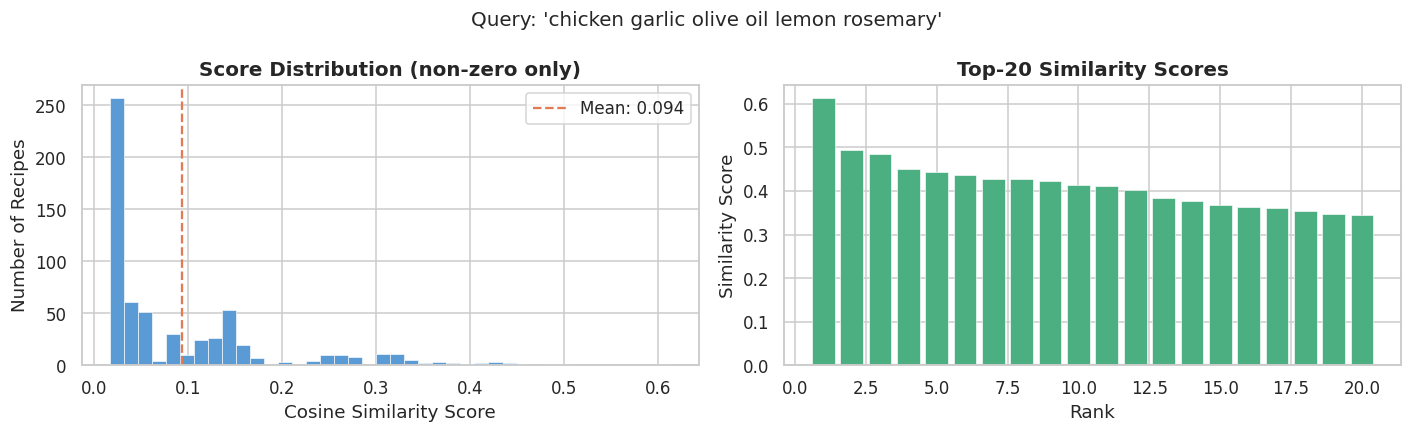

Non-zero matching recipes: 626 out of 1000
Coverage: 62.6%


In [17]:
# ── 7b. Score distribution for a sample query ─────────────────────────────
test_query = "chicken garlic olive oil lemon rosemary"
scores = get_similarity_scores(test_query, tfidf_matrix, vectorizer)
nonzero_scores = scores[scores > 0]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(nonzero_scores, bins=40, color="#5B9BD5", edgecolor="white", linewidth=0.4)
axes[0].set_xlabel("Cosine Similarity Score", fontsize=12)
axes[0].set_ylabel("Number of Recipes", fontsize=12)
axes[0].set_title("Score Distribution (non-zero only)", fontsize=13, fontweight="bold")
axes[0].axvline(nonzero_scores.mean(), color="#E07B54", linestyle="--",
                label="Mean: " + str(round(nonzero_scores.mean(), 3)))
axes[0].legend()

# Top-20 scores
top20 = np.sort(scores)[::-1][:20]
axes[1].bar(range(1, 21), top20, color="#4CAF82", edgecolor="white", linewidth=0.4)
axes[1].set_xlabel("Rank", fontsize=12)
axes[1].set_ylabel("Similarity Score", fontsize=12)
axes[1].set_title("Top-20 Similarity Scores", fontsize=13, fontweight="bold")

plt.suptitle("Query: '" + test_query + "'", fontsize=13)
plt.tight_layout()
plt.show()

print("Non-zero matching recipes:", len(nonzero_scores), "out of", len(df))
print("Coverage: " + str(round(len(nonzero_scores) / len(df) * 100, 1)) + "%")


In [18]:
# ── 7c. Filter precision test ──────────────────────────────────────────────
# Check that ALL results from filtered recommendation satisfy the filter

def test_filter_precision(query, filter_name, filter_col, threshold, comparison):
    """
    comparison: 'ge' (>=) or 'le' (<=)
    """
    kw = {filter_name: True}
    res = recommend_filtered(query, top_n=20, **kw)
    if res.empty:
        return None
    if comparison == "ge":
        satisfied = (res[filter_col] >= threshold).all()
    else:
        satisfied = (res[filter_col] <= threshold).all()
    return {
        "filter": filter_name,
        "results": len(res),
        "all_satisfy": satisfied,
        "min_val": round(res[filter_col].min(), 1),
        "max_val": round(res[filter_col].max(), 1),
    }

hp_test = test_filter_precision("chicken beef turkey", "filter_high_protein", "protein_g", 25, "ge")
lc_test = test_filter_precision("salad vegetables soup", "filter_low_calorie",  "calories",  400, "le")

print("Filter Precision Tests:")
print()
for t in [hp_test, lc_test]:
    if t:
        ok = "PASS" if t["all_satisfy"] else "FAIL"
        print("[" + ok + "] " + t["filter"])
        print("      Results returned :", t["results"])
        print("      All satisfy filter:", t["all_satisfy"])
        print("      Value range       : " + str(t["min_val"]) + " – " + str(t["max_val"]))
        print()


Candidate pool after filters: 607 recipes
Candidate pool after filters: 312 recipes
Filter Precision Tests:

[PASS] filter_high_protein
      Results returned : 20
      All satisfy filter: True
      Value range       : 26.2 – 51.4

[PASS] filter_low_calorie
      Results returned : 20
      All satisfy filter: True
      Value range       : 144.9 – 398.6



In [19]:
# ── 7d. Recall@K — fraction of relevant recipes retrieved ─────────────────
# We define 'relevant' as: similarity score in top 10% of all scores

def recall_at_k(query, k=10, relevance_threshold=0.05):
    """
    Returns the fraction of 'relevant' recipes captured in the top-K.
    Relevant = similarity score >= relevance_threshold.
    """
    scores = get_similarity_scores(query, tfidf_matrix, vectorizer)
    relevant_mask = scores >= relevance_threshold
    n_relevant = relevant_mask.sum()
    if n_relevant == 0:
        return 0.0, 0
    top_k_idx = np.argsort(scores)[::-1][:k]
    hits = relevant_mask[top_k_idx].sum()
    return round(hits / n_relevant, 4), n_relevant

test_queries = [
    "chicken garlic lemon",
    "salmon dill butter",
    "tofu ginger soy sauce",
    "lentils cumin turmeric",
    "eggs cheese spinach",
]

print("Recall@K Evaluation (threshold=0.05):")
print("-" * 55)
print("Query" + " "*35 + "Recall@5  Recall@10  Total Relevant")
print("-" * 55)
for q in test_queries:
    r5,  n = recall_at_k(q, k=5)
    r10, _ = recall_at_k(q, k=10)
    qd = (q[:38] + "...") if len(q) > 38 else q
    print(qd.ljust(40) + str(r5).ljust(10) + str(r10).ljust(11) + str(n))


Recall@K Evaluation (threshold=0.05):
-------------------------------------------------------
Query                                   Recall@5  Recall@10  Total Relevant
-------------------------------------------------------
chicken garlic lemon                    0.0224    0.0448     223
salmon dill butter                      0.0407    0.0813     123
tofu ginger soy sauce                   0.0806    0.1613     62
lentils cumin turmeric                  0.0649    0.1299     77
eggs cheese spinach                     0.0253    0.0505     198


## Step 8 — Interactive Query Demo

In [20]:
# ── A clean display function ───────────────────────────────────────────────
def display_recommendations(results):
    """Pretty-print recommendation results."""
    if results.empty:
        print("No recommendations found.")
        return

    print()
    print("=" * 65)
    for _, row in results.iterrows():
        print("  #" + str(int(row["rank"])) + "  " + str(row["recipe_name"]))
        print("      Similarity   : " + str(row["similarity_score"]))
        print("      Calories     : " + str(round(row["calories"], 0)) + " kcal")
        print("      Protein      : " + str(round(row["protein_g"], 1)) + " g")
        print("      Fat          : " + str(round(row["fat_g"], 1)) + " g")
        print("      Carbs        : " + str(round(row["carbs_g"], 1)) + " g")
        print("      Cuisine      : " + str(row.get("primary_cuisine", "—")))
        labels = row.get("diet_labels", [])
        if isinstance(labels, list) and labels:
            print("      Diet labels  : " + ", ".join(labels))
        print("-" * 65)


# ── Demo 1: No filters ────────────────────────────────────────────────────
print("DEMO 1: What can I make with 'salmon butter dill capers'?")
res = recommend("salmon butter dill capers", top_n=5)
display_recommendations(res)


DEMO 1: What can I make with 'salmon butter dill capers'?

  #1  Pan-Seared Salmon with Dill #562
      Similarity   : 0.5345
      Calories     : 533.0 kcal
      Protein      : 52.0 g
      Fat          : 14.5 g
      Carbs        : 48.7 g
      Cuisine      : Mediterranean
-----------------------------------------------------------------
  #2  Teriyaki Salmon Bowl #262
      Similarity   : 0.4452
      Calories     : 562.0 kcal
      Protein      : 41.5 g
      Fat          : 19.2 g
      Carbs        : 55.8 g
      Cuisine      : Japanese
-----------------------------------------------------------------
  #3  Teriyaki Salmon Bowl #742
      Similarity   : 0.4406
      Calories     : 357.0 kcal
      Protein      : 18.9 g
      Fat          : 20.1 g
      Carbs        : 25.1 g
      Cuisine      : Japanese
-----------------------------------------------------------------
  #4  Teriyaki Salmon Bowl #622
      Similarity   : 0.4288
      Calories     : 417.0 kcal
      Protein      : 

In [21]:
# ── Demo 2: High protein only ─────────────────────────────────────────────
print("DEMO 2: High-protein meal with 'chicken breast quinoa spinach'")
res = recommend_filtered("chicken breast quinoa spinach", top_n=5,
                          filter_high_protein=True)
display_recommendations(res)


DEMO 2: High-protein meal with 'chicken breast quinoa spinach'
Candidate pool after filters: 607 recipes

  #1  Chicken Caesar Salad #621
      Similarity   : 0.4263
      Calories     : 458.0 kcal
      Protein      : 29.0 g
      Fat          : 26.0 g
      Carbs        : 27.0 g
      Cuisine      : American
-----------------------------------------------------------------
  #2  Chicken Caesar Salad #421
      Similarity   : 0.4115
      Calories     : 599.0 kcal
      Protein      : 46.2 g
      Fat          : 30.0 g
      Carbs        : 36.1 g
      Cuisine      : American
-----------------------------------------------------------------
  #3  Grilled Lemon Herb Chicken #41
      Similarity   : 0.3971
      Calories     : 322.0 kcal
      Protein      : 28.1 g
      Fat          : 3.8 g
      Carbs        : 43.9 g
      Cuisine      : American
-----------------------------------------------------------------
  #4  Chicken Caesar Salad #181
      Similarity   : 0.3806
      Calories

In [22]:
# ── Demo 3: Low calorie only ──────────────────────────────────────────────
print("DEMO 3: Light meal with 'zucchini tomato basil garlic'")
res = recommend_filtered("zucchini tomato basil garlic", top_n=5,
                          filter_low_calorie=True)
display_recommendations(res)


DEMO 3: Light meal with 'zucchini tomato basil garlic'
Candidate pool after filters: 312 recipes

  #1  Spaghetti Bolognese #786
      Similarity   : 0.4252
      Calories     : 192.0 kcal
      Protein      : 16.5 g
      Fat          : 10.2 g
      Carbs        : 8.5 g
      Cuisine      : Italian
-----------------------------------------------------------------
  #2  Spaghetti Bolognese #186
      Similarity   : 0.3806
      Calories     : 333.0 kcal
      Protein      : 15.0 g
      Fat          : 10.7 g
      Carbs        : 44.2 g
      Cuisine      : Italian
-----------------------------------------------------------------
  #3  Beef Pasta Bake #766
      Similarity   : 0.1595
      Calories     : 296.0 kcal
      Protein      : 8.6 g
      Fat          : 22.2 g
      Carbs        : 15.4 g
      Cuisine      : Italian
-----------------------------------------------------------------
  #4  Beef Pasta Bake #526
      Similarity   : 0.1446
      Calories     : 392.0 kcal
      Prote

In [23]:
# ── Demo 4: Diet label filter ─────────────────────────────────────────────
print("DEMO 4: High-fiber meal with 'lentils chickpeas black beans'")
res = recommend_filtered("lentils chickpeas black beans", top_n=5,
                          diet_label_filter="high-fiber")
display_recommendations(res)


DEMO 4: High-fiber meal with 'lentils chickpeas black beans'
Candidate pool after filters: 245 recipes

  #1  Bean Burrito Bowl #672
      Similarity   : 0.3325
      Calories     : 182.0 kcal
      Protein      : 5.2 g
      Fat          : 14.7 g
      Carbs        : 7.1 g
      Cuisine      : Mexican
-----------------------------------------------------------------
  #2  Cuban Black Beans & Rice #252
      Similarity   : 0.3255
      Calories     : 513.0 kcal
      Protein      : 6.1 g
      Fat          : 29.1 g
      Carbs        : 56.7 g
      Cuisine      : American
-----------------------------------------------------------------
  #3  Southwest Quinoa Bowl #570
      Similarity   : 0.3204
      Calories     : 488.0 kcal
      Protein      : 42.7 g
      Fat          : 2.9 g
      Carbs        : 72.7 g
      Cuisine      : Mexican
-----------------------------------------------------------------
  #4  Southwest Quinoa Bowl #890
      Similarity   : 0.3085
      Calories     : 29

In [24]:
# ── Demo 5: Combined — high protein + low calorie ─────────────────────────
print("DEMO 5: High-protein AND low-calorie with 'turkey eggs cottage cheese'")
res = recommend_filtered("turkey eggs cottage cheese", top_n=5,
                          filter_high_protein=True,
                          filter_low_calorie=True)
display_recommendations(res)


DEMO 5: High-protein AND low-calorie with 'turkey eggs cottage cheese'
Candidate pool after filters: 119 recipes

  #1  Cottage Cheese Berry Bowl #99
      Similarity   : 0.3487
      Calories     : 380.0 kcal
      Protein      : 42.8 g
      Fat          : 11.5 g
      Carbs        : 26.4 g
      Cuisine      : American
-----------------------------------------------------------------
  #2  Cottage Cheese Berry Bowl #379
      Similarity   : 0.2674
      Calories     : 321.0 kcal
      Protein      : 54.1 g
      Fat          : 7.4 g
      Carbs        : 9.6 g
      Cuisine      : American
-----------------------------------------------------------------
  #3  Cottage Cheese Berry Bowl #979
      Similarity   : 0.2616
      Calories     : 368.0 kcal
      Protein      : 35.6 g
      Fat          : 13.5 g
      Carbs        : 26.1 g
      Cuisine      : American
-----------------------------------------------------------------
  #4  High Protein Pancakes #599
      Similarity   : 0.26

## Step 9 — Save the Fitted Model

In [25]:
import pickle

Path("models").mkdir(exist_ok=True)

# Save vectorizer and matrix together
model_bundle = {
    "vectorizer": vectorizer,
    "tfidf_matrix": tfidf_matrix,
    "df_index": df.index.tolist(),
}

with open("models/tfidf_model.pkl", "wb") as f:
    pickle.dump(model_bundle, f)

print("Model saved to models/tfidf_model.pkl")
print()
print("To reload in app.py:")
print("  import pickle")
print("  with open('models/tfidf_model.pkl', 'rb') as f:")
print("      bundle = pickle.load(f)")
print("  vectorizer   = bundle['vectorizer']")
print("  tfidf_matrix = bundle['tfidf_matrix']")


Model saved to models/tfidf_model.pkl

To reload in app.py:
  import pickle
  with open('models/tfidf_model.pkl', 'rb') as f:
      bundle = pickle.load(f)
  vectorizer   = bundle['vectorizer']
  tfidf_matrix = bundle['tfidf_matrix']


In [26]:
# Final summary
print("=" * 55)
print("   Recommender System — Summary")
print("=" * 55)
print("  Dataset size     :", len(df), "recipes")
print("  Vocabulary size  :", len(vectorizer.vocabulary_))
print("  TF-IDF shape     :", tfidf_matrix.shape)
print("  Filters available: high_protein, low_calorie, diet_label")
print("  Model saved to   : models/tfidf_model.pkl")
print("=" * 55)


   Recommender System — Summary
  Dataset size     : 1000 recipes
  Vocabulary size  : 891
  TF-IDF shape     : (1000, 891)
  Filters available: high_protein, low_calorie, diet_label
  Model saved to   : models/tfidf_model.pkl
